# Diabetes Dataset — Exploratory Data Analysis (EDA)

## Objective
The objective of this project is to perform a structured exploratory analysis of the diabetes dataset using Python. We will understand the dataset, assess data quality, explore distributions and relationships, identify unusual values/outliers, and derive data-driven insights.

> **Important:** `Outcome` is treated as the dataset's recorded diabetes outcome label. The analysis describes patterns in this dataset; it does not establish medical causation or provide a clinical diagnosis.

### Analytical Questions
1. What does the dataset look like and what are the data types?
2. Are there missing, duplicate, or potentially invalid values?
3. How are the numerical variables distributed?
4. How do key variables differ across the two outcome groups?
5. Which variables have the strongest observed linear correlation with `Outcome`?
6. What outliers or unusual zero values should be considered before further modeling?
7. What are the main findings from the EDA?

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid')

## 2. Load the Dataset

In [3]:
df = pd.read_csv('C:/Users/pradh/Downloads/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.60,0.63,50,1
1,1,85,66,29,0,26.60,0.35,31,0
2,8,183,64,0,0,23.30,0.67,32,1
3,1,89,66,23,94,28.10,0.17,21,0
4,0,137,40,35,168,43.10,2.29,33,1


### Insight
- The dataset contains **768 records** and **9 variables**.
- The target column is `Outcome`, with two recorded classes: **0 (negative)** and **1 (positive)**.
- The dataset is therefore suitable for a focused binary-outcome EDA, while still requiring careful treatment of unusual values.

## 3. Dataset Structure

In [3]:
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nData types:')
display(df.dtypes.to_frame('dtype'))

Shape: (768, 9)

Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:


,dtype
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


## 4. First Look at the Data

In [4]:
display(df.head())
display(df.tail())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.60,0.63,50,1
1,1,85,66,29,0,26.60,0.35,31,0
2,8,183,64,0,0,23.30,0.67,32,1
3,1,89,66,23,94,28.10,0.17,21,0
4,0,137,40,35,168,43.10,2.29,33,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.90,0.17,63,0
764,2,122,70,27,0,36.80,0.34,27,0
765,5,121,72,23,112,26.20,0.24,30,0
766,1,126,60,0,0,30.10,0.35,47,1
767,1,93,70,31,0,30.40,0.32,23,0


## 5. Descriptive Statistics

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.00,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,768.00,120.89,31.97,0.00,99.00,117.00,140.25,199.00
BloodPressure,768.00,69.11,19.36,0.00,62.00,72.00,80.00,122.00
SkinThickness,768.00,20.54,15.95,0.00,0.00,23.00,32.00,99.00
Insulin,768.00,79.80,115.24,0.00,0.00,30.50,127.25,846.00
BMI,768.00,31.99,7.88,0.00,27.30,32.00,36.60,67.10
DiabetesPedigreeFunction,768.00,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.00,33.24,11.76,21.00,24.00,29.00,41.00,81.00
Outcome,768.00,0.35,0.48,0.00,0.00,0.00,1.00,1.00


### Insight
- `Glucose` ranges from **0 to 199**, while `BMI` ranges from **0.0 to 67.1**.
- `Insulin` has a wide range (**0 to 846**) and a relatively large standard deviation (**115.2**), suggesting substantial dispersion.
- Several variables have a minimum of **0**, which requires separate data-quality investigation because zero may not be a plausible physiological measurement for some fields.

## 6. Missing Values

In [6]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean()*100).sort_values(ascending=False)
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_summary

,Missing Count,Missing %
Pregnancies,0,0.00
Glucose,0,0.00
BloodPressure,0,0.00
SkinThickness,0,0.00
Insulin,0,0.00
BMI,0,0.00
DiabetesPedigreeFunction,0,0.00
Age,0,0.00
Outcome,0,0.00


### Insight
- There are **no explicit NaN/null values** in the dataset.
- However, absence of NaN values does **not** guarantee complete data quality because several clinical-style variables contain zero values that may represent unavailable measurements.

## 7. Duplicate Records

In [7]:
duplicate_count = df.duplicated().sum()
print('Duplicate rows:', duplicate_count)

Duplicate rows: 0


### Insight
- The dataset contains **0 exact duplicate rows**.
- Because duplicates can artificially increase the frequency of repeated observations, they should be reviewed before modeling. In this dataset, no duplicate-row removal is required if the count is zero.

## 8. Investigating Zero Values

In [8]:
zero_summary = pd.DataFrame({
    'Zero Count': df.eq(0).sum(),
    'Zero %': df.eq(0).mean()*100
}).sort_values('Zero Count', ascending=False)
zero_summary

,Zero Count,Zero %
Outcome,500,65.10
Insulin,374,48.70
SkinThickness,227,29.56
Pregnancies,111,14.45
BloodPressure,35,4.56
BMI,11,1.43
Glucose,5,0.65
DiabetesPedigreeFunction,0,0.00
Age,0,0.00


### Insight
- Zero values are present in several variables where a zero can be questionable as a measured physiological value.
- In particular, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` should be reviewed rather than automatically interpreted as genuine measurements.
- For EDA, we retain the original dataset and separately create a version where these questionable zeros are represented as missing values. This avoids silently changing the source data.

## 9. Outcome Distribution

In [9]:
outcome_counts = df['Outcome'].value_counts().sort_index()
outcome_pct = df['Outcome'].value_counts(normalize=True).sort_index()*100
outcome_summary = pd.DataFrame({'Count': outcome_counts, 'Percentage': outcome_pct})
outcome_summary.index = ['Outcome 0', 'Outcome 1']
outcome_summary

,Count,Percentage
Outcome 0,500,65.10
Outcome 1,268,34.90


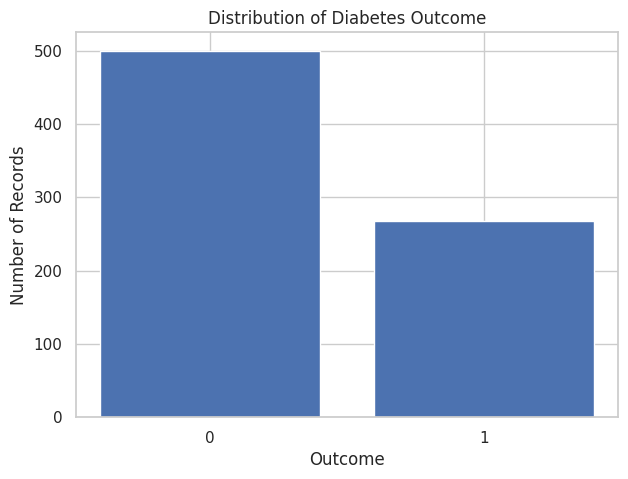

In [10]:
plt.figure(figsize=(7,5))
plt.bar(outcome_counts.index.astype(str), outcome_counts.values)
plt.title('Distribution of Diabetes Outcome')
plt.xlabel('Outcome')
plt.ylabel('Number of Records')
plt.show()

### Insight
- **500 (65.1%)** records have `Outcome = 0`.
- **268 (34.9%)** records have `Outcome = 1`.
- The classes are not perfectly balanced, so class proportions should be considered when interpreting group comparisons or any later predictive model.

## 10. Univariate Analysis — Numerical Distributions

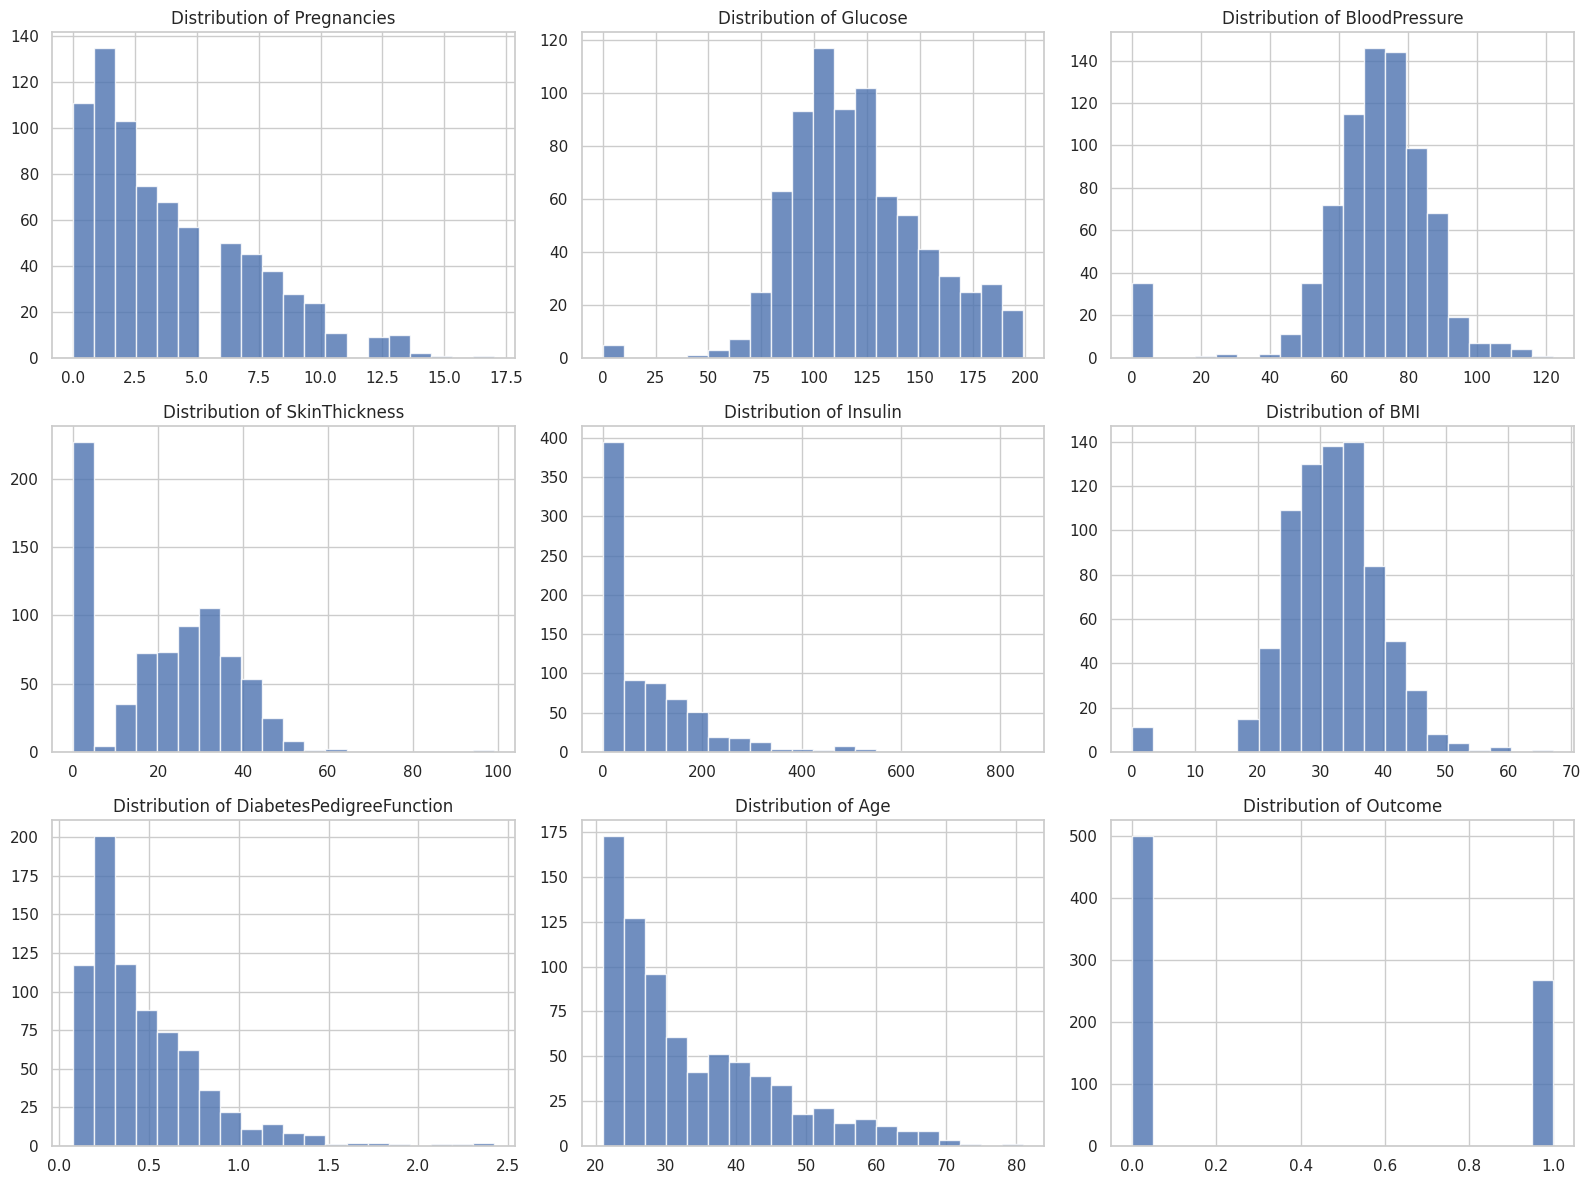

In [11]:
numeric_cols = df.columns.tolist()
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=20, alpha=0.8)
    axes[i].set_title(f'Distribution of {col}')
for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

### Insight
- `Glucose`, `BMI`, and `Age` show broad distributions with noticeable variation across records.
- `Insulin` is strongly right-skewed, with a small number of observations far above the central range.
- `DiabetesPedigreeFunction` is also right-skewed, indicating that a relatively small number of observations have much larger values than the typical record.

## 11. Boxplot-Based Outlier Exploration

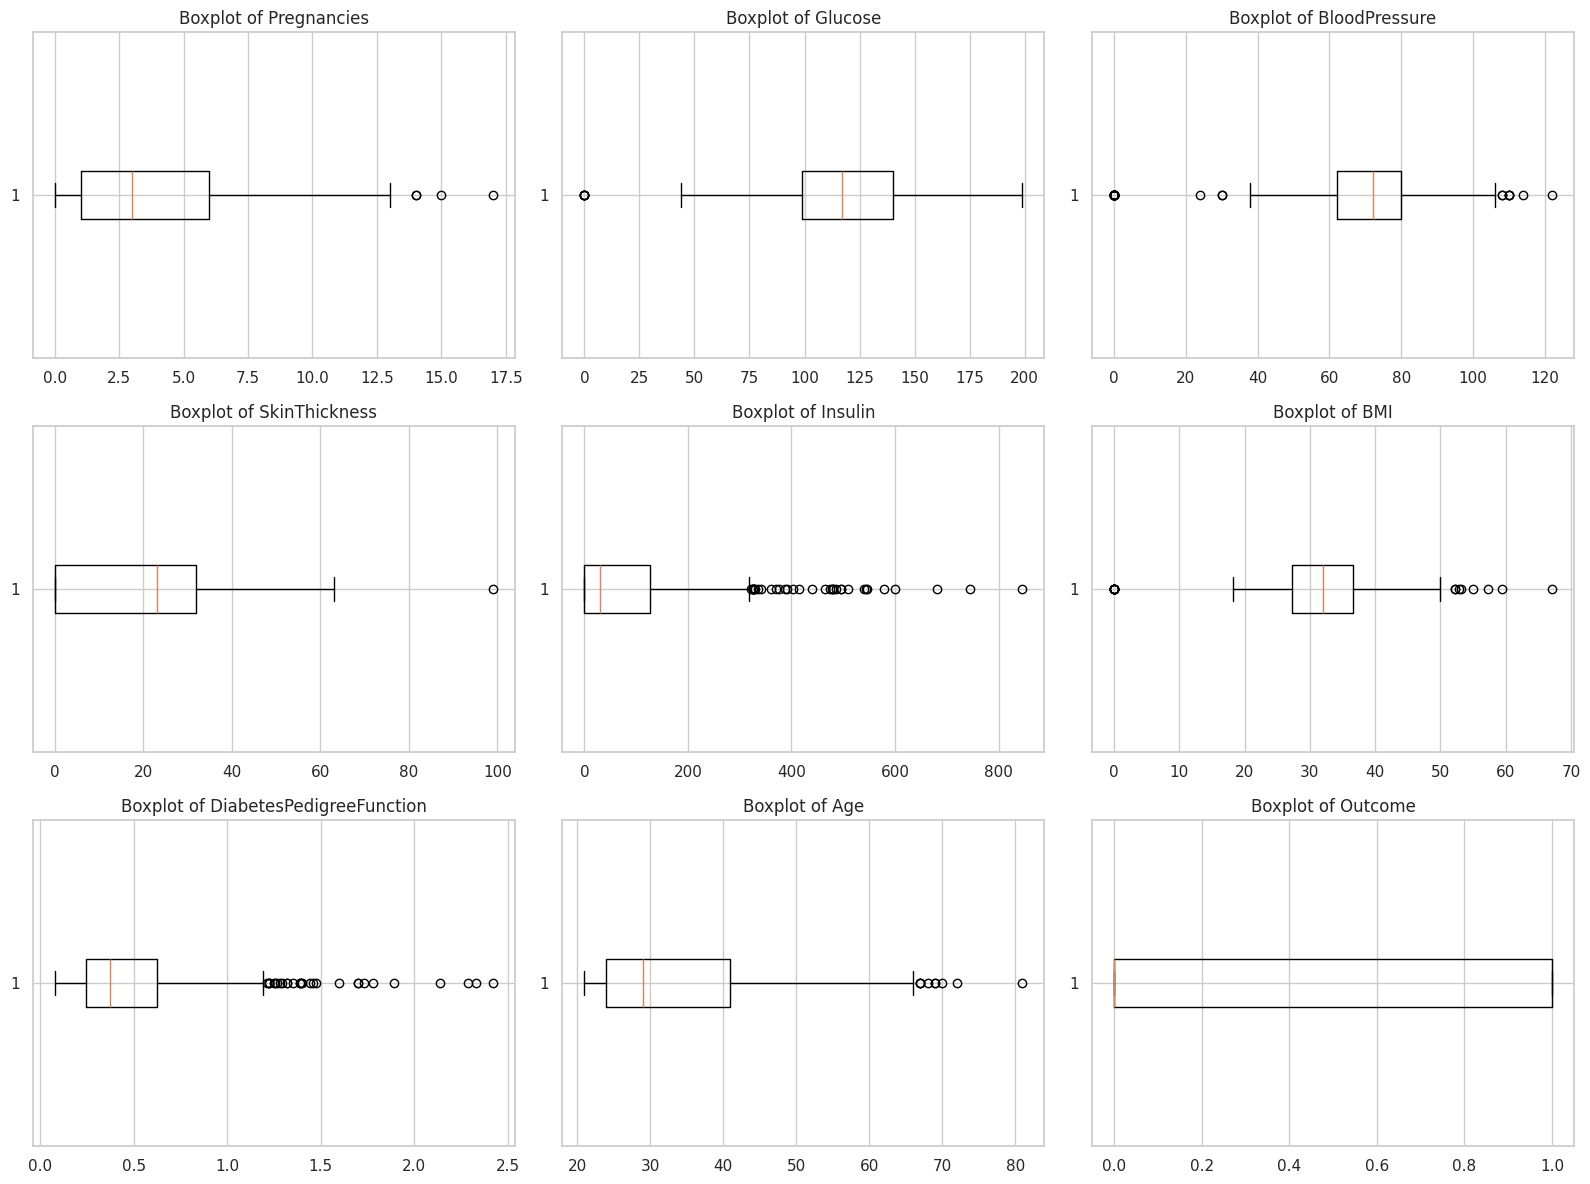

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), vert=False)
    axes[i].set_title(f'Boxplot of {col}')
for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

In [13]:
outlier_summary = []
for col in df.columns[:-1]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, q1, q3, iqr, lower, upper, count])
outlier_df = pd.DataFrame(outlier_summary, columns=['Column','Q1','Q3','IQR','Lower Bound','Upper Bound','Outlier Count'])
outlier_df.sort_values('Outlier Count', ascending=False)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
2,BloodPressure,62.00,80.00,18.00,35.00,107.00,45
4,Insulin,0.00,127.25,127.25,-190.88,318.12,34
6,DiabetesPedigreeFunction,0.24,0.63,0.38,-0.33,1.20,29
5,BMI,27.30,36.60,9.30,13.35,50.55,19
7,Age,24.00,41.00,17.00,-1.50,66.50,9
1,Glucose,99.00,140.25,41.25,37.12,202.12,5
0,Pregnancies,1.00,6.00,5.00,-6.50,13.50,4
3,SkinThickness,0.00,32.00,32.00,-48.00,80.00,1


### Insight
- The IQR method flags unusually high values in several variables, but an outlier is not automatically an error.
- `Insulin` has especially strong dispersion, so its extreme values should be investigated before any transformation or modeling.
- Outlier handling should be based on domain knowledge and analytical purpose rather than deleting observations simply because they fall outside the IQR limits.

## 12. Relationship Between Features and Outcome

In [14]:
group_summary = df.groupby('Outcome')[['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']].agg(['mean','median'])
group_summary

Pregnancies        Glucose        BloodPressure        SkinThickness  \
               mean median    mean median          mean median          mean   
Outcome                                                                        
0              3.30   2.00  109.98 107.00         68.18  70.00         19.66   
1              4.87   4.00  141.26 140.00         70.82  74.00         22.16   

               Insulin          BMI        DiabetesPedigreeFunction         \
        median    mean median  mean median                     mean median   
Outcome                                                                      
0        21.00   68.79  39.00 30.30  30.05                     0.43   0.34   
1        27.00  100.34   0.00 35.14  34.25                     0.55   0.45   

          Age         
         mean median  
Outcome               
0       31.19  27.00  
1       37.07  36.00

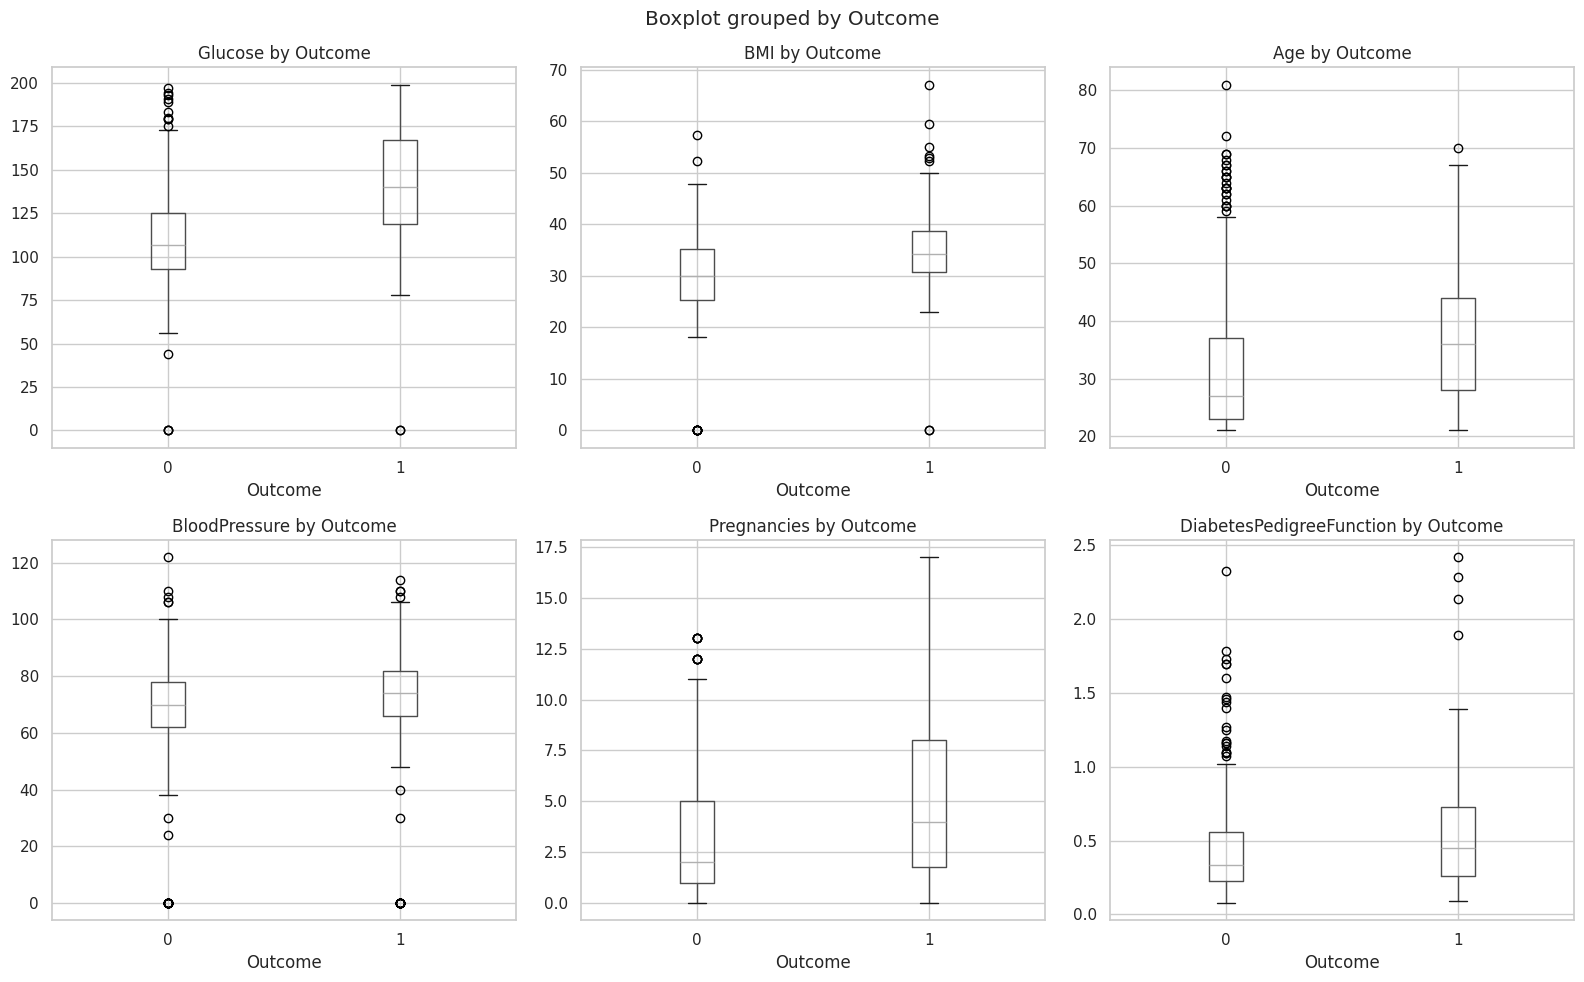

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features = ['Glucose','BMI','Age','BloodPressure','Pregnancies','DiabetesPedigreeFunction']
for ax, col in zip(axes.flat, features):
    df.boxplot(column=col, by='Outcome', ax=ax)
    ax.set_title(f'{col} by Outcome')
plt.tight_layout()
plt.show()

### Insight
- The mean `Glucose` level is **110.0** for Outcome 0 and **141.3** for Outcome 1.
- The mean `BMI` is **30.3** for Outcome 0 and **35.1** for Outcome 1.
- The mean `Age` is **31.2** for Outcome 0 and **37.1** for Outcome 1.
- These group-level differences show that several variables have different distributions across the recorded outcome groups. They describe association in this dataset and should not be interpreted as proof of causation.

## 13. Glucose Analysis

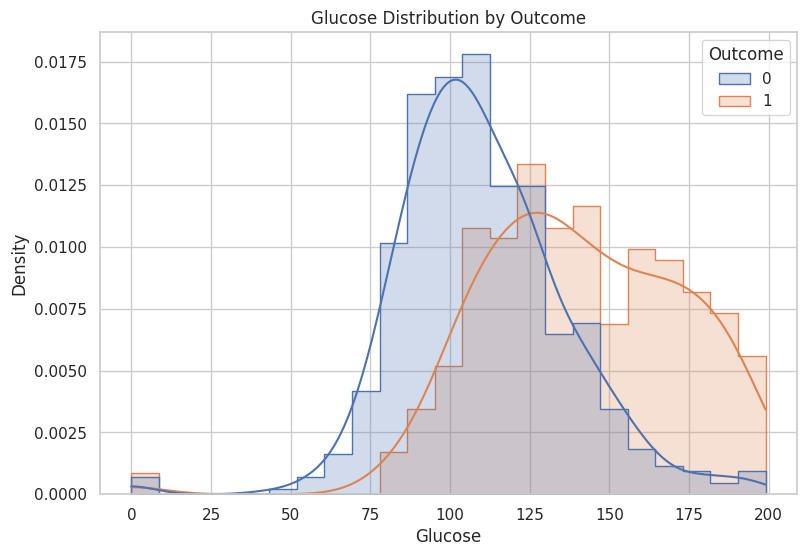

In [16]:
plt.figure(figsize=(9,6))
sns.histplot(data=df, x='Glucose', hue='Outcome', kde=True, element='step', stat='density', common_norm=False)
plt.title('Glucose Distribution by Outcome')
plt.show()

In [17]:
glucose_bins = [0, 100, 125, 140, 200]
glucose_labels = ['<100','100-124','125-139','140+']
temp = df.copy()
temp['Glucose_Range'] = pd.cut(temp['Glucose'], bins=glucose_bins, labels=glucose_labels, right=False)
glucose_outcome = pd.crosstab(temp['Glucose_Range'], temp['Outcome'], normalize='index')*100
glucose_outcome

Outcome,0,1
Glucose_Range,,
<100,91.88,8.12
100-124,73.46,26.54
125-139,57.89,42.11
140+,31.47,68.53


### Insight
- The outcome groups show visibly different glucose distributions, with the positive-outcome group concentrated more toward higher glucose values.
- The glucose-band table provides a more granular view than a single average and helps identify how the recorded outcome proportion changes across glucose ranges.

## 14. BMI Analysis

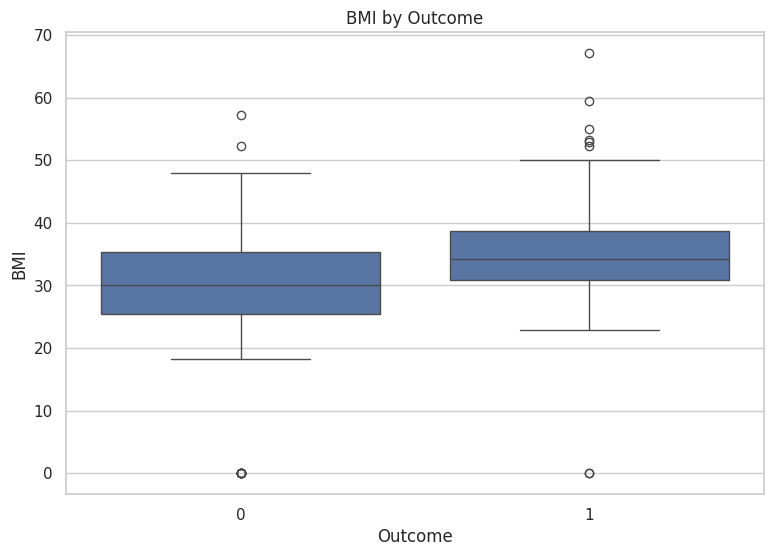

In [18]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df, x='Outcome', y='BMI')
plt.title('BMI by Outcome')
plt.show()

### Insight
- BMI distributions overlap between the two outcome groups, but the central tendency is higher for the positive-outcome group in this dataset.
- The overlap indicates that BMI alone does not cleanly separate the two groups; multiple variables should be considered together.

## 15. Age Analysis

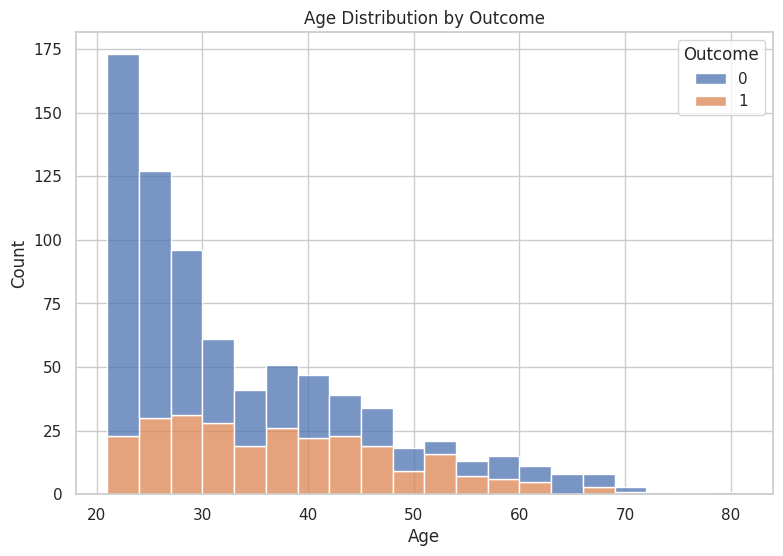

In [19]:
plt.figure(figsize=(9,6))
sns.histplot(data=df, x='Age', hue='Outcome', multiple='stack', bins=20)
plt.title('Age Distribution by Outcome')
plt.show()

### Insight
- The dataset contains adults from **21 to 81 years**.
- The positive-outcome group has a higher average age than the negative-outcome group, while the distributions still overlap substantially.
- This suggests age is informative at a group level but should not be used as a standalone separator.

## 16. Correlation Analysis

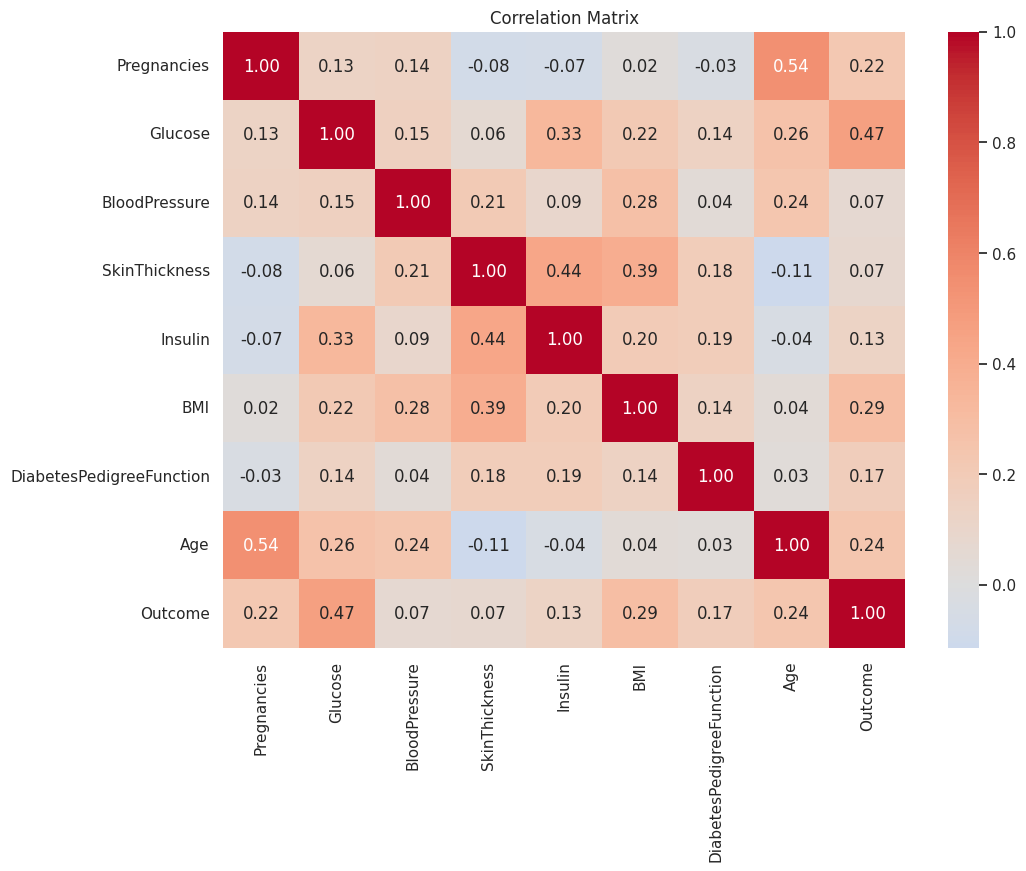

In [20]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(11,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [21]:
outcome_corr = corr_matrix['Outcome'].drop('Outcome').sort_values(key=lambda x: x.abs(), ascending=False)
outcome_corr.to_frame('Correlation with Outcome')

,Correlation with Outcome
Glucose,0.47
BMI,0.29
Age,0.24
Pregnancies,0.22
DiabetesPedigreeFunction,0.17
Insulin,0.13
SkinThickness,0.07
BloodPressure,0.07


### Insight
- The variables with the largest absolute Pearson correlations with `Outcome` in this dataset are **Glucose (0.47)**, **BMI (0.29)**, and **Age (0.24)**.
- Correlation measures linear association and does not imply causation. It also does not capture every type of nonlinear relationship.
- The heatmap should therefore be used as an exploratory signal rather than a definitive feature-importance measure.

## 17. Pairwise Relationships of Key Variables

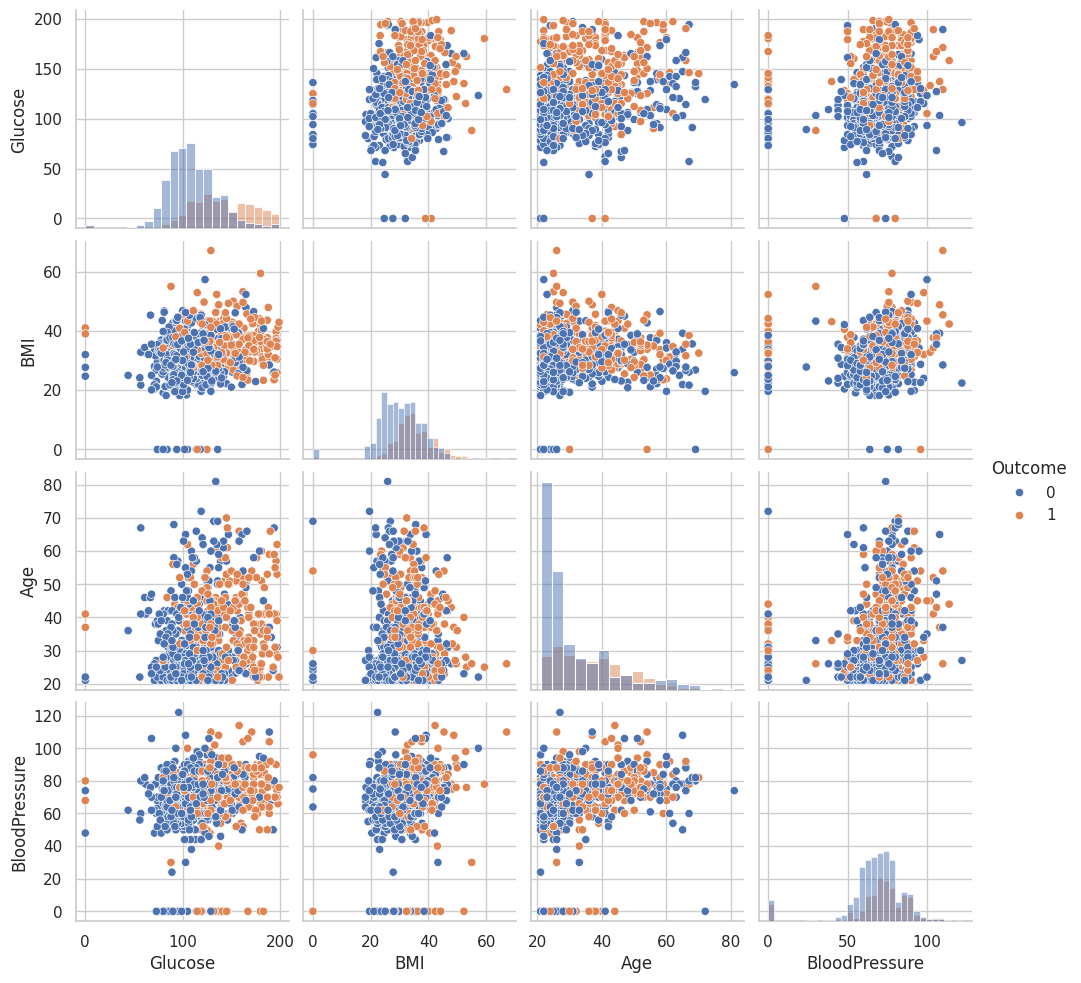

In [22]:
key_features = ['Glucose','BMI','Age','BloodPressure','Outcome']
sns.pairplot(df[key_features], hue='Outcome', diag_kind='hist')
plt.show()

### Insight
- Pairwise plots make it easier to see the overlap between outcome groups.
- Some combinations, particularly those involving `Glucose`, show more visible separation than others, but there is still substantial overlap.
- This supports the use of multivariable analysis rather than relying on a single feature.

## 18. Creating an EDA-Friendly Clean Copy

In [23]:
df_eda = df.copy()
possible_missing_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in possible_missing_cols:
    df_eda[col] = df_eda[col].replace(0, np.nan)

df_eda.isna().sum().to_frame('Missing after zero review')

,Missing after zero review
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


### Insight
- A separate `df_eda` copy is created so that questionable zero values can be handled transparently without altering the original data.
- At this stage, we do not automatically impute the values because the appropriate treatment depends on the intended downstream analysis.
- Keeping both `df` and `df_eda` preserves reproducibility and makes the cleaning decision explicit.

## 19. Key EDA Findings

### Summary of Findings
1. **Dataset size:** The dataset contains **768 rows and 9 columns**.
2. **Target distribution:** Outcome 0 represents **65.1%**, while Outcome 1 represents **34.9%** of records.
3. **Missing values:** There are no explicit null values, but several variables contain potentially problematic zeros.
4. **Zero-value issue:** `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` contain zero entries that should be reviewed before modeling.
5. **Distribution:** `Insulin` is strongly right-skewed and contains extreme values relative to its central range.
6. **Outcome differences:** `Glucose`, `BMI`, and `Age` show noticeable differences in their distributions between the two recorded outcome groups.
7. **Correlation:** `Glucose` has the strongest absolute linear correlation with `Outcome` among the variables in this dataset, followed by other features identified in the correlation table.
8. **Outliers:** IQR-based analysis identifies potential outliers in multiple variables; these should be investigated rather than automatically removed.
9. **Overall interpretation:** The EDA suggests that diabetes outcome is associated with a combination of measurable characteristics in this dataset, so a multivariable approach would be more appropriate than relying on one variable alone.

## 20. Conclusion

This exploratory analysis established the structure, quality, distributions, relationships, and major anomalies in the diabetes dataset. The most important preparation issue is the presence of zero values in variables where zero may represent an unavailable measurement rather than a genuine observation. The analysis also shows meaningful differences between the two outcome groups, particularly for glucose-related measurements, while substantial overlap remains.

For a next step, the cleaned dataset can be used for feature engineering and a separate predictive-modeling workflow. Any model should be evaluated using appropriate validation and classification metrics rather than relying only on accuracy.